# Deep FCNN on Tiny ImageNet
**Author**: Deadlyharbor aka Aman Gupta and Vansh Pandey

## Task Description - 3.1
- Dataset: Tiny ImageNet (10 classes subset)
- Model: Deep FCNN (8 layers)
- Experiments:
    - Exp A: Sigmoid, No Batch Norm
    - Exp B: Leaky ReLU (0.01), Batch Norm
- Optimizer: AdamW

## Expectations in 3.1
- Small gradient norms and VGP in sigmoid activation function as NN is deep
- Learning occurs while relu is used with batch normalization as there will be no VGP.
- FCNN is used for images so overfitting without dropout is expected in task 1.
- Simplifiying the network architecture to lesser n[l] per layer may also reduce overfitting 
- Speed of training in relu will be faster due to reduce exponential operations

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check CUDA
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
Device Name: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Data Parsing and Utils

In [ ]:
def get_data_loaders(data_dir, batch_size=64):
    # We are using Standard transformation for Tiny ImageNet (64x64)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Standard Tiny ImageNet structure: 'train' and 'val' folders
    train_dir = os.path.join(data_dir, 'tiny-imagenet', 'train')
    val_dir = os.path.join(data_dir, 'tiny-imagenet', 'val')
    
    if not os.path.exists(train_dir) or not os.path.exists(val_dir):
        print(f"Hey change this path carefully - {data_dir}/tiny-imagenet")
        return None, None

    # Load datasets directly from folders
    train_dataset = ImageFolder(root=train_dir, transform=transform)
    val_dataset = ImageFolder(root=val_dir, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    print(f"Classes: {train_dataset.classes}")
    print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
    
    return train_loader, val_loader

# Constants
DATA_DIR = '../../../datasets'
BATCH_SIZE = 64
NUM_CLASSES = 10
INPUT_DIM = 64 * 64 * 3 # 12288 

## 2. Network Architecture

In [ ]:
class DeepFCNN(nn.Module):
    def __init__(self, activation='sigmoid', use_batch_norm=False):
        super(DeepFCNN, self).__init__()
        self.use_batch_norm = use_batch_norm
        self.layers = nn.ModuleList()
        
        # Architecture: 12288 -> 512, 256, 256, 128, 128, 64, 32 -> 10
        #  512 is good starting point and then reducing no of features
        dims = [INPUT_DIM, 512, 256, 256, 128, 128, 64, 32, NUM_CLASSES]
        
        for i in range(len(dims) - 1):
            self.layers.append(nn.Linear(dims[i], dims[i+1]))
            
            # Add activation and BN for all except last layer
            if i < len(dims) - 2:
                if use_batch_norm:
                    self.layers.append(nn.BatchNorm1d(dims[i+1]))
                
                if activation == 'sigmoid':
                    self.layers.append(nn.Sigmoid())
                elif activation == 'leaky_relu':
                    self.layers.append(nn.LeakyReLU(0.01))
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return x

## 3. Training Loop & Utils

In [4]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'layer1_grad_norm': [], 'time_per_epoch': []
    }
    
    print(f"Starting training on {device}...")
    
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        
        # Track gradient norm for first layer
        epoch_grad_norms = []
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Capture grad norm of first linear layer (index 0 in ModuleList)
            # The first layer is always at index 0
            first_layer_grad = model.layers[0].weight.grad.norm().item()
            epoch_grad_norms.append(first_layer_grad)
            
            optimizer.step()
            running_loss += loss.item()
        
        epoch_time = time.time() - start_time
        avg_train_loss = running_loss / len(train_loader)
        avg_grad_norm = np.mean(epoch_grad_norms)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['layer1_grad_norm'].append(avg_grad_norm)
        history['time_per_epoch'].append(epoch_time)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Time: {epoch_time:.2f}s "
              f"Train Loss: {avg_train_loss:.4f} "
              f"Val Loss: {avg_val_loss:.4f} "
              f"Val Acc: {val_acc:.2f}% "
              f"Grad Norm: {avg_grad_norm:.4f}")
              
    return history

## 4. Run Experiments

In [5]:
# Setup Data
train_loader, val_loader = get_data_loaders(DATA_DIR, BATCH_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if train_loader:
    # EXP A: Sigmoid, No Batch Norm
    print("\n--- Experiment A: Sigmoid ---")
    model_a = DeepFCNN(activation='sigmoid', use_batch_norm=False)
    history_a = train_model(model_a, train_loader, val_loader, epochs=20, device=device)

    # EXP B: Leaky ReLU + Batch Norm
    print("\n--- Experiment B: Leaky ReLU + BN ---")
    model_b = DeepFCNN(activation='leaky_relu', use_batch_norm=True)
    history_b = train_model(model_b, train_loader, val_loader, epochs=20, device=device)
else:
    print("Data loaders failed to initialize. Check path.")

Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']
Train size: 3500, Val size: 500
Using device: cuda

--- Experiment A: Sigmoid ---
Starting training on cuda...
Epoch [1/20] Time: 26.03s Train Loss: 2.3070 Val Loss: 2.2829 Val Acc: 17.40% Grad Norm: 0.0005
Epoch [2/20] Time: 7.34s Train Loss: 2.1858 Val Loss: 2.0960 Val Acc: 17.60% Grad Norm: 0.0263
Epoch [3/20] Time: 7.34s Train Loss: 2.0413 Val Loss: 2.0536 Val Acc: 18.60% Grad Norm: 0.1293
Epoch [4/20] Time: 6.98s Train Loss: 1.9851 Val Loss: 2.0045 Val Acc: 19.40% Grad Norm: 0.1780
Epoch [5/20] Time: 7.79s Train Loss: 1.9669 Val Loss: 1.9628 Val Acc: 19.60% Grad Norm: 0.1861
Epoch [6/20] Time: 7.11s Train Loss: 1.9530 Val Loss: 1.9741 Val Acc: 19.60% Grad Norm: 0.1927
Epoch [7/20] Time: 7.03s Train Loss: 1.9287 Val Loss: 1.9745 Val Acc: 19.60% Grad Norm: 0.1330
Epoch [8/20] Time: 7.47s Train Loss: 1.9034 Val Loss: 1.9171 Val Acc: 22.40% Grad N

## 5. Plot Results

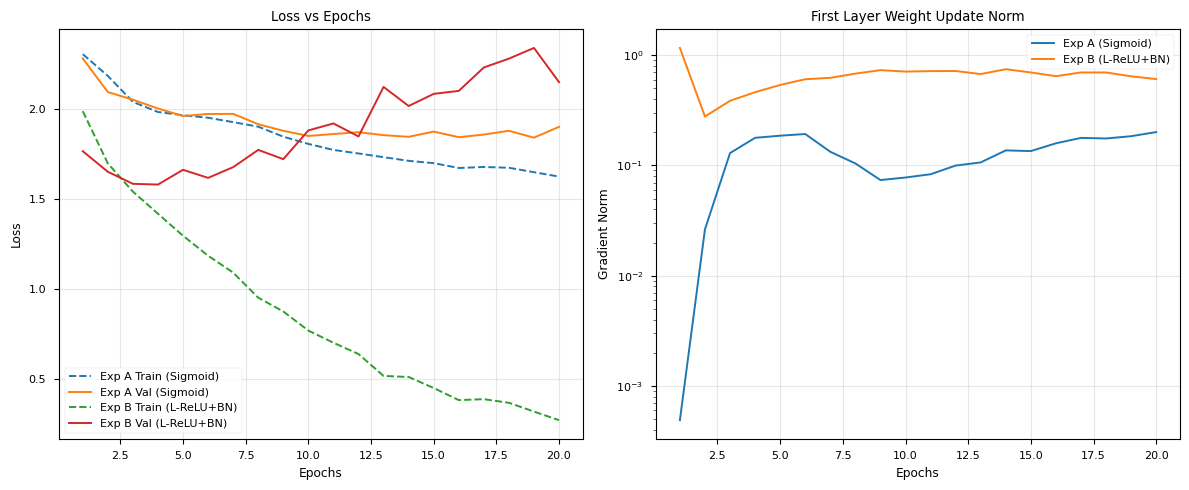

Plots saved to plots/comparison_plot.png


In [ ]:
os.makedirs('plots', exist_ok=True)

if train_loader:
    epochs = range(1, 21)

    # Plot Loss Comparison
    plt.figure(figsize=(12, 5))
    plt.style.use('seaborn-v0_8-paper')
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_a['train_loss'], label='Exp A Train (Sigmoid)', linestyle='--')
    plt.plot(epochs, history_a['val_loss'], label='Exp A Val (Sigmoid)')
    plt.plot(epochs, history_b['train_loss'], label='Exp B Train (L-ReLU+BN)', linestyle='--')
    plt.plot(epochs, history_b['val_loss'], label='Exp B Val (L-ReLU+BN)')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Gradient Norms
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_a['layer1_grad_norm'], label='Exp A (Sigmoid)')
    plt.plot(epochs, history_b['layer1_grad_norm'], label='Exp B (L-ReLU+BN)')
    plt.title('First Layer Weight Update Norm')
    plt.xlabel('Epochs')
    plt.ylabel('Gradient Norm')
    plt.yscale('log') 
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('plots/comparison_plot.png', dpi=300)
    plt.show()
    
    print("Plots saved to plots/comparison_plot.png")

In [ ]:
# Expectations matched

# Task 3.2 goes from here